In [ ]:
from __future__ import division

import numpy as np
import glob
import matplotlib.pyplot as plt
import scipy.linalg as sl

import enterprise
from enterprise.pulsar import Pulsar
import enterprise.signals.parameter as parameter
from enterprise.signals import utils
from enterprise.signals import signal_base
from enterprise.signals import selections
from enterprise.signals.selections import Selection
from enterprise.signals import white_signals
from enterprise.signals import gp_signals
from enterprise.signals import deterministic_signals
import pint

import corner
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc

In [ ]:
def get_noise_from_pal2(noisefile):
    psrname = noisefile.split('/')[-1].split('_noise.txt')[0]
    fin = open(noisefile, 'r')
    lines = fin.readlines()
    params = {}
    for line in lines:
        ln = line.split()
        if 'efac' in line:
            par = 'efac'
            flag = ln[0].split('efac-')[-1]
        elif 'equad' in line:
            par = 'log10_t2equad'
            flag = ln[0].split('equad-')[-1]
        elif 'jitter_q' in line:
            par = 'log10_ecorr'
            flag = ln[0].split('jitter_q-')[-1]
        elif 'RN-Amplitude' in line:
            par = 'log10_A'
            flag = ''
        elif 'RN-spectral-index' in line:
            par = 'gamma'
            flag = ''
        else:
            break
        if flag:
            name = [psrname, flag, par]
        else:
            name = [psrname, par]
        pname = '_'.join(name)
        params.update({pname: float(ln[1])})
    return params


In [ ]:
import pta_replicator

from pta_replicator.white_noise import add_measurement_noise
from pta_replicator.white_noise import add_jitter
from pta_replicator.red_noise import add_red_noise, add_gwb
from pta_replicator.simulate import load_pulsar, load_from_directories, simulate_pulsar
from pta_replicator.simulate import make_ideal

In [ ]:
from pathlib import Path

datadir = '/Users/dalloncarlson/Documents/WFU/VIPER_Mini_Project/VIPER-2026/VIPER-2026/NANOGrav15yr_PulsarTiming_v2.1.0/narrowband'

parfiles = sorted(glob.glob(datadir + '/par/*.par'))
timfiles = sorted(glob.glob(datadir + '/tim/*.tim'))
noisefiles = sorted(glob.glob(datadir + '/noise/*.txt'))

pardir = datadir + '/par'
timdir = datadir + '/tim'
viperdir = str(Path(datadir).resolve().parent.parent)
dictdir = viperdir + '/nanograv15yr_cw/15yr_cw_analysis-main/data'

print(pardir)
print(timdir)
print(dictdir)

In [ ]:
# psrs = [Pulsar(par, tim) for par, tim in zip(parfiles, timfiles)]
psrs = load_from_directories(pardir, timdir, num_psrs=2)  # Load 2 pulsars

# for p, t in zip(parfiles, timfiles):
#     psr = Pulsar(p, t, ephem='DE421')
#     psrs.append(psr)

print(psrs)

In [ ]:
import json

with open(dictdir + '/v1p1_all_dict.json', 'r') as fp:
    noise_params = json.load(fp)
# change number strings to floats:
for value in noise_params.values():
    value = float(value)

In [ ]:
psrlist = [psr.name for psr in psrs]
noise_dict = {}
for p in psrlist:
    noise_dict[p] = {}
    noise_dict[p]['log10_equads'] = []
    noise_dict[p]['efacs'] = []
    noise_dict[p]['log10_ecorrs'] = []
    for ky in list(noise_params.keys()):
        if p in ky:
            if 'equad' in ky:
                noise_dict[p]['log10_equads'].append([ky.replace(p + '_' , '').replace('_log10_t2equad', ''), noise_params[ky]])
            if 'efac' in ky:
                noise_dict[p]['efacs'].append([ky.replace(p + '_' , '').replace('_efac', ''), noise_params[ky]])
            if 'ecorr' in ky:
                noise_dict[p]['log10_ecorrs'].append([ky.replace(p + '_' , '').replace('_log10_ecorr', ''), noise_params[ky]])
            if 'gamma' in ky:
                noise_dict[p]['rn_gamma'] = noise_params[ky]
            if 'log10_A' in ky:
                noise_dict[p]['rn_log10_amp'] = noise_params[ky]
                
    noise_dict[p]['log10_equads'] = np.array(noise_dict[p]['log10_equads'])
    noise_dict[p]['efacs'] = np.array(noise_dict[p]['efacs'])
    noise_dict[p]['log10_ecorrs'] = np.array(noise_dict[p]['log10_ecorrs'])

In [ ]:
## By using seeds we can  reproduce the dataset if need be. 
seed_efac_equad = 10660
seed_jitter = 17763
seed_red = 19870
seed_gwb = 15672

In [85]:
for ii, psr in enumerate(psrs):

    ## make ideal
    make_ideal(psr)
    print(make_ideal.__doc__)
    ## add efacs
    ## if you use flags, the flags and efac and equad values all need to have the same number of elements
    add_measurement_noise(psr, efac = noise_dict[psr.name]['efacs'][:,1].astype(float),
                          log10_equad = noise_dict[psr.name]['log10_equads'][:,1].astype(float), 
                          flagid = 'f', flags = noise_dict[psr.name]['efacs'][:,0], 
                          seed = seed_efac_equad + ii)

    ## add jitter
    add_jitter(psr, log10_ecorr = noise_dict[psr.name]['log10_ecorrs'][:,1].astype(float), 
                flagid='f', flags = noise_dict[psr.name]['log10_ecorrs'][:,0], 
                coarsegrain = 1.0/86400.0, seed = seed_jitter + ii)

    ## add red noise
    add_red_noise(psr,
                  log10_amplitude = noise_dict[psr.name]['rn_log10_amp'],
                  spectral_index = noise_dict[psr.name]['rn_gamma'],
                  components = 30, seed = seed_red + ii)

    print(ii, psr.name)

2026-07-23 17:09:36.520 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:1042 - ECL not specified; using IERS2010.
2026-07-23 17:09:36.524 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:1042 - ECL not specified; using IERS2010.
2026-07-23 17:09:36.529 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:1042 - ECL not specified; using IERS2010.
2026-07-23 17:09:36.552 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:1042 - ECL not specified; using IERS2010.
2026-07-23 17:09:36.593 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:1042 - ECL not specified; using IERS2010.
2026-07-23 17:09:36.594 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:1042 - ECL not specified; using IERS2010.
2026-07-23 17:09:36.597 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:1042 - ECL not specified; using IERS2010.
2026-07-23 17:09:36.608 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:1042 - ECL not specified; using IERS2010.
2026-07-23 17:09:37.234 | DEBUG 


    Takes a pint.TOAs and pint.TimingModel object and effectively zeros out the residuals.
    


2026-07-23 17:09:41.971 | DEBUG    | pint.toa:compute_TDBs:2278 - Computing TDB columns.
2026-07-23 17:09:41.971 | DEBUG    | pint.toa:compute_TDBs:2280 - tdb column already exists. Deleting...
2026-07-23 17:09:41.971 | DEBUG    | pint.toa:compute_TDBs:2283 - tdbld column already exists. Deleting...
2026-07-23 17:09:41.971 | DEBUG    | pint.toa:compute_TDBs:2299 - Using EPHEM = DE440 for TDB calculation.
2026-07-23 17:09:42.310 | DEBUG    | pint.toa:compute_posvels:2374 - Computing PosVels of observatories, Earth and planets, using DE440
2026-07-23 17:09:42.310 | DEBUG    | pint.toa:compute_posvels:2384 - Column ssb_obs_pos already exists. Removing...
2026-07-23 17:09:42.311 | DEBUG    | pint.toa:compute_posvels:2384 - Column ssb_obs_vel already exists. Removing...
2026-07-23 17:09:42.311 | DEBUG    | pint.toa:compute_posvels:2384 - Column obs_sun_pos already exists. Removing...
2026-07-23 17:09:42.311 | DEBUG    | pint.toa:compute_posvels:2389 - Column obs_jupiter_pos already exists. 

0 B1855+09


2026-07-23 17:09:49.124 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:1042 - ECL not specified; using IERS2010.
2026-07-23 17:09:49.132 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:1042 - ECL not specified; using IERS2010.
2026-07-23 17:09:49.146 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:1042 - ECL not specified; using IERS2010.
2026-07-23 17:09:49.167 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:1042 - ECL not specified; using IERS2010.
2026-07-23 17:09:49.245 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:1042 - ECL not specified; using IERS2010.
2026-07-23 17:09:49.246 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:1042 - ECL not specified; using IERS2010.
2026-07-23 17:09:49.251 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:1042 - ECL not specified; using IERS2010.
2026-07-23 17:09:49.259 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:1042 - ECL not specified; using IERS2010.
2026-07-23 17:09:51.622 | DEBUG 


    Takes a pint.TOAs and pint.TimingModel object and effectively zeros out the residuals.
    


2026-07-23 17:10:05.461 | DEBUG    | pint.toa:compute_TDBs:2278 - Computing TDB columns.
2026-07-23 17:10:05.461 | DEBUG    | pint.toa:compute_TDBs:2280 - tdb column already exists. Deleting...
2026-07-23 17:10:05.462 | DEBUG    | pint.toa:compute_TDBs:2283 - tdbld column already exists. Deleting...
2026-07-23 17:10:05.462 | DEBUG    | pint.toa:compute_TDBs:2299 - Using EPHEM = DE440 for TDB calculation.
2026-07-23 17:10:06.922 | DEBUG    | pint.toa:compute_posvels:2374 - Computing PosVels of observatories, Earth and planets, using DE440
2026-07-23 17:10:06.922 | DEBUG    | pint.toa:compute_posvels:2384 - Column ssb_obs_pos already exists. Removing...
2026-07-23 17:10:06.923 | DEBUG    | pint.toa:compute_posvels:2384 - Column ssb_obs_vel already exists. Removing...
2026-07-23 17:10:06.923 | DEBUG    | pint.toa:compute_posvels:2384 - Column obs_sun_pos already exists. Removing...
2026-07-23 17:10:06.923 | DEBUG    | pint.toa:compute_posvels:2389 - Column obs_jupiter_pos already exists. 

1 B1937+21


In [ ]:
add_gwb(psrs, log10_amplitude = -15, spectral_index = 13./3., seed = seed_gwb)

In [ ]:
for psr in psrs:
    print(psr.added_signals)

In [ ]:
for psr in psrs:
    plt.errorbar(psr.toas.get_mjds(), psr.residuals.time_resids.to_value("us"),
                 psr.residuals.get_data_error().to_value("us"), marker="+", ls="", label="Total")
    for sig in psr.added_signals_time:
        plt.plot(psr.toas.get_mjds(), psr.added_signals_time[sig].to_value("us"),
                 marker='x', label=sig, ls="", zorder=5, alpha=0.5)
    plt.legend()
    plt.xlabel("MJD")
    plt.ylabel("Residuals (us)")
    plt.show()
    plt.clf()

    print(psr.toas.get_mjds())



In [88]:
import os

sim_tim_dir = './simulated_tims'
os.makedirs(sim_tim_dir, exist_ok=True)

ent_psrs = []

# each simulated pulsar from the psrs list is saved to a .tim file and then loaded into an enterprise Pulsar object
for psr in psrs:
    sim_tim_path = os.path.join(sim_tim_dir, f"{psr.name}_sim.tim")
    psr.toas.write_TOA_file(sim_tim_path)
    
    par_file = [p for p in parfiles if psr.name in p][0]
    
    # Initialize a native enterprise Pulsar object
    print(f"Loading {psr.name} into enterprise...")
    ent_psr = Pulsar(par_file, sim_tim_path, ephem='DE440') # or 'DE421' if using an older dataset
    ent_psrs.append(ent_psr)

2026-07-23 17:17:24.254 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2019 from the given model


Loading B1855+09 into enterprise...


2026-07-23 17:17:25.218 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2026-07-23 17:17:25.785 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-07-23 17:17:25.786 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2019) clock correction (~27 us)
2026-07-23 17:17:25.787 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2026-07-23 17:17:26.843 | DEBUG    | pint.toa:compute_TDBs:2278 - Computing TDB columns.
2026-07-23 17:17:26.843 | DEBUG    | pint.toa:compute_TDBs:2299 - Using EPHEM = DE440 for TDB calculation.
2026-07-23 17:17:27.187 | DEBUG    | pint.toa:get_TOAs:310 - Planet PosVels will be calculated.
2026-07-23 17:17:27.187 | DEBUG    | pint.toa:compute_posvels:2374 - Computing PosVels of observatories, Earth and planets, using DE440
2026-07-23 17:17:27.267 | I

Loading B1937+21 into enterprise...


2026-07-23 17:17:41.886 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2019 from the given model
2026-07-23 17:17:44.744 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2026-07-23 17:17:44.924 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-07-23 17:17:44.925 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2019) clock correction (~27 us)
2026-07-23 17:17:44.926 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2026-07-23 17:17:46.614 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-07-23 17:17:46.615 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2019) clock correction (~27 us)
2026-07-23 17:17:46.616 | INFO     | pint.observatory.topo_obs:clock_corrections:340

In [107]:
pulsartime = []

for psr in psrs:
    pulsartime.append((np.min(psr.toas.get_mjds().value), np.max(psr.toas.get_mjds().value)))

print(pulsartime)

tmin = np.min(pulsartime)
tmax = np.max(pulsartime)

print(tmin)
print(tmax)
Tspan = tmax - tmin
print(Tspan)

# selection class to break white noise by backend
selection = selections.Selection(selections.by_backend)

##### Parameters and Priors #####

# white noise
efac = parameter.Constant()
t2equad = parameter.Constant()
ecorr = parameter.Constant()

# red noise
log10_A_rn = parameter.Constant()
gamma_rn = parameter.Constant()

# gwb parameters we are sampling
log10_A_gw = parameter.Uniform(-18, -13)('gw_log10_A')
gamma_gw = parameter.Uniform(0, 7)('gw_gamma')

##### Set up signals #####

# timing model
tm = gp_signals.TimingModel(use_svd=True)

# white noise
ef_eq = white_signals.MeasurementNoise(efac=efac, log10_t2equad=t2equad, selection=selection)
ec = white_signals.EcorrKernelNoise(log10_ecorr=ecorr, selection=selection)

# red noise (powerlaw with 30 frequencies)
pl_rn = utils.powerlaw(log10_A=log10_A_rn, gamma=gamma_rn)
rn = gp_signals.FourierBasisGP(spectrum=pl_rn, components=30, Tspan=Tspan)

# GWB (Uncorrelated common red process)
cpl = utils.powerlaw(log10_A=log10_A_gw, gamma=gamma_gw)
gw = gp_signals.FourierBasisGP(spectrum=cpl, components=30, Tspan=Tspan, name='gw')

s = tm + ef_eq + ec + rn + gw

model = [s(p) for p in ent_psrs]

pta = signal_base.PTA(model)
pta.set_default_params(noise_params)

print("Sampled parameters:", pta.param_names)

[(np.float64(53358.72747171815), np.float64(59051.16494936884)), (np.float64(53267.08600495323), np.float64(59065.12904887423))]
53267.08600495323
59065.12904887423
5798.043043921003
Sampled parameters: ['gw_gamma', 'gw_log10_A']


In [100]:
missing_params = []
for m in model: # Using the list of pulsar models you already built
    for sig in m.signals:
        for param in sig.params:
            if hasattr(param, 'value') and param.value is None:
                missing_params.append(param.name)

print("=== DIAGNOSTIC ===")
print(f"Number of missing parameters: {len(missing_params)}")
if len(missing_params) > 0:
    # Print a unique list of missing parameters
    print(f"Missing parameters: {list(set(missing_params))[:10]}")
    
print(f"Total keys loaded in noise_dict: {len(noise_dict)}")
if len(noise_dict) > 0:
    print(f"First 5 keys in noise_dict: {list(noise_dict.keys())[:5]}")
print("==================")

=== DIAGNOSTIC ===
Number of missing parameters: 0
Total keys loaded in noise_dict: 2
First 5 keys in noise_dict: ['B1855+09', 'B1937+21']


In [105]:
# xs = {par.name: par.sample() for par in pta.params}
# print(pta.get_lnlikelihood(xs))
# print(pta.get_lnprior(xs))
# # dimension of parameter space
# ndim = len(xs)

# # initial jump covariance matrix
# cov = np.diag(np.ones(ndim) * 0.01**2)

# # set up jump groups by red noise groups
# ndim = len(xs)
# groups  = [range(0, ndim)]
# groups.extend(map(list, zip(range(0,ndim,2), range(1,ndim,2))))
# groups.extend([[36]])

# sampler = ptmcmc(ndim, pta.get_lnlikelihood, pta.get_lnprior, cov, groups=groups,
#                  outDir='chains/nano_9_gwb/')

# # sampler for N steps
# N = 1000000
# x0 = np.hstack(p.sample() for p in pta.params)
# sampler.sample(x0, N, SCAMweight=30, AMweight=15, DEweight=50, )
# chain = np.loadtxt('chains/nano_9_gwb/chain_1.txt')
# pars = sorted(xs.keys())
# burn = int(0.25 * chain.shape[0])
# plt.hist(chain[burn:,-5], 50, normed=True, histtype='step', lw=2);
# plt.xlabel(pars[-1]);


In [138]:
# 1. Provide an initial guess by drawing random starting points from your priors
x0 = np.hstack([p.sample() for p in pta.params])
ndim = len(x0)

# 2. Set up the initial jump covariance matrix
# This defines the typical step size the MCMC will initially take
cov = np.diag(np.ones(ndim) * 0.01**2)

# 3. Define the output directory for the MCMC chains
outdir = './mcmc_ground_truth'
os.makedirs(outdir, exist_ok=True)

# 4. Initialize the sampler
# The enterprise PTA object natively provides the log-likelihood and log-prior functions
sampler = ptmcmc(ndim, pta.get_lnlikelihood, pta.get_lnprior, cov, 
                 outDir=outdir, resume=False)

# 5. Run the sampler
# For a 2-parameter model, 500,000 steps is generally plenty for a well-converged posterior
N_steps = int(50000)
print(f"Starting MCMC for {N_steps} steps...")

sampler.sample(x0, N_steps, SCAMweight=30, AMweight=15, DEweight=50)

Starting MCMC for 50000 steps...
Finished 2.00 percent in 3.138913 s Acceptance rate = 0.656

Finished 20.00 percent in 21.400168 s Acceptance rate = 0.165667Adding DE jump with weight 50
Finished 100.00 percent in 100.477885 s Acceptance rate = 0.28912
Run Complete


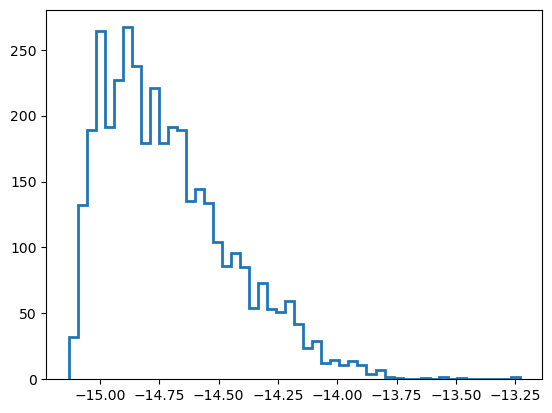

In [146]:
chain = np.loadtxt(outdir +'/chain_1.txt')
burn = int(0.25 * chain.shape[0])
samples = chain[:, :ndim]
plt.hist(chain[burn:,-5], 50, histtype='step', lw=2);
labels = pta.param_names

# You injected GWB with amplitude -15 and gamma 13/3
if labels[0] == 'gw_gamma':
    truths = [13./3., -15.0]
else:
    truths = [-15.0, 13./3.]



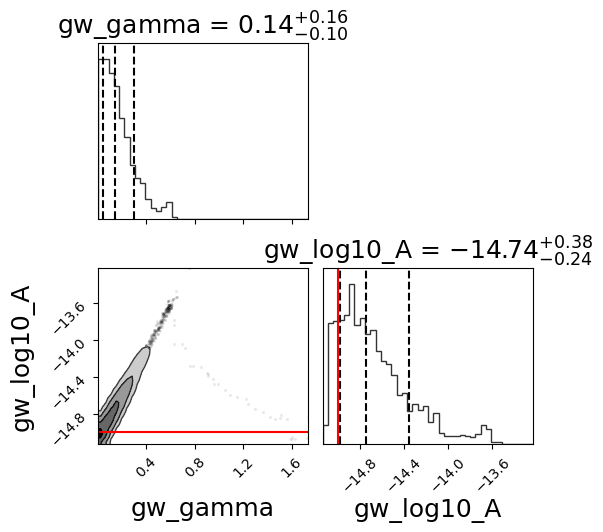

In [174]:
# fig = plt.figure(figsize=(10, 10), dpi=300)
fig = corner.corner(
    samples,
    labels=labels,
    truths=truths,
    truth_color='red',
    bins=40,
    smooth=1.0,
    plot_density=True,
    fill_contours=True,
    contour_kwargs={"linewidths": 1.0, "alpha": 0.7},
    hist_kwargs={"density": True, "alpha": 0.8},
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 18},
    label_kwargs={"fontsize": 18},
    # fig=fig,
)
plt.tight_layout()
plt.show()

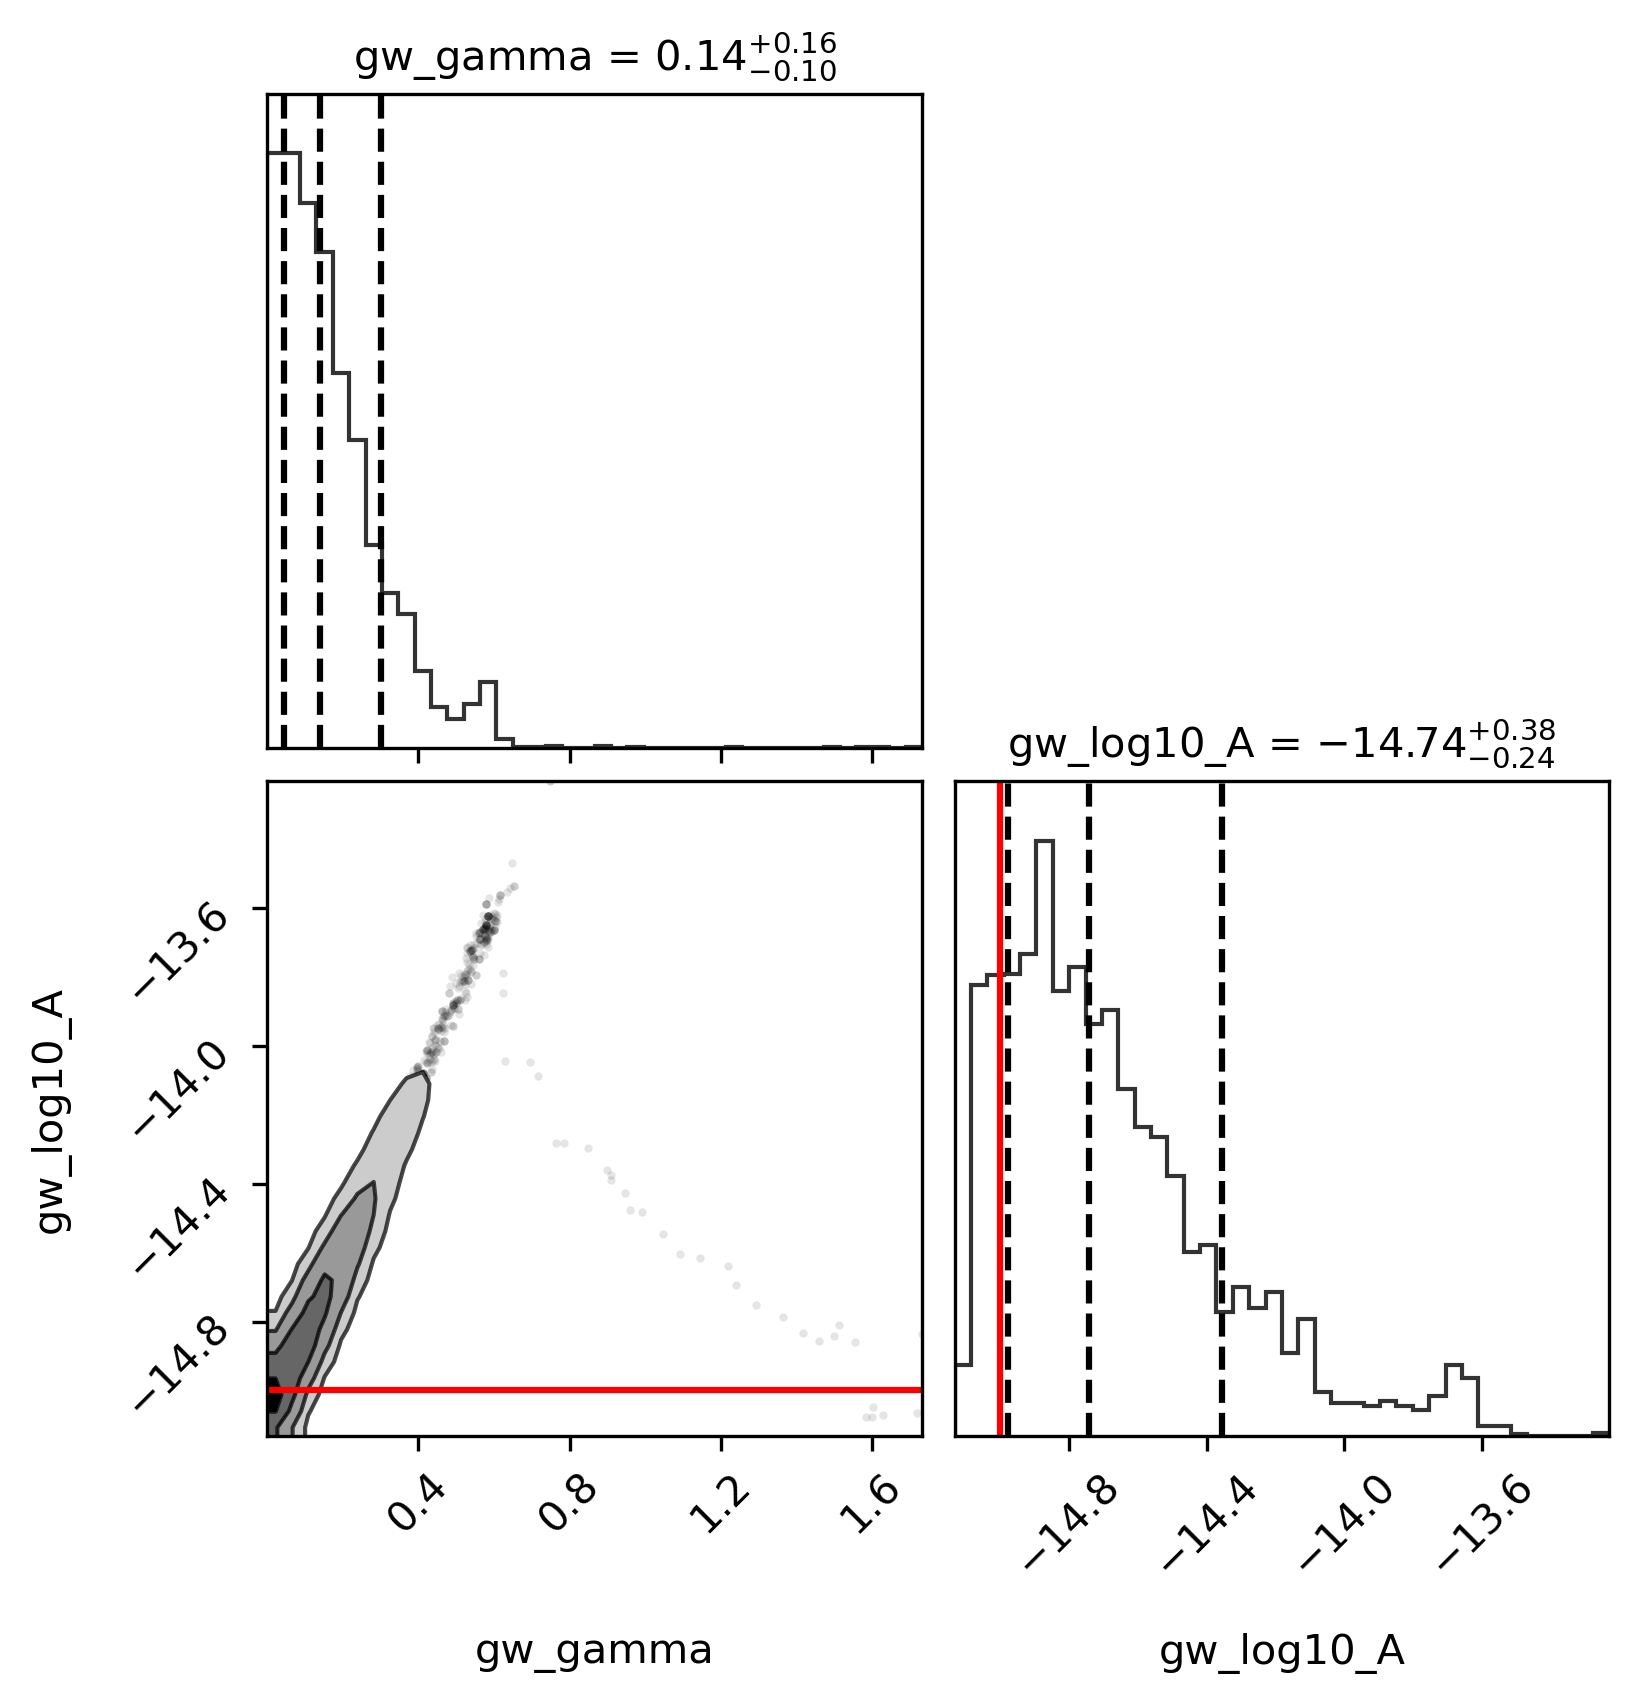

In [ ]:
fig = plt.figure(figsize=(6, 6), dpi=300)

figure = corner.corner(
    samples,
    truths=truths,
    labels=labels,
    truth_color='red',
    bins=40,
    smooth=1.0,
    plot_density=True,
    fill_contours=True,
    contour_kwargs={"linewidths": 1.0, "alpha": 0.7},
    hist_kwargs={"density": True, "alpha": 0.8},
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 15},
    label_kwargs={"fontsize": 10},
    fig=fig
    )